# Data and Valuation Problem Setup (Economic Perspective)

This notebook builds the initial modeling dataset for explaining cross-sectional variation in EV/EBITDA using accounting, profitability, growth, investment, leverage, and liquidity ratios.

From a corporate finance perspective, EV/EBITDA is used as a market-implied valuation multiple that captures operating value before capital structure effects. The objective is therefore not only statistical cleaning, but also economic consistency: each filtering decision aims to remove observations that are likely to be accounting artifacts, extreme one-offs, or structurally incomparable firms.

Methodologically, the pipeline follows a practical quant workflow:
1. Define a coherent feature set linked to valuation theory.
2. Diagnose missingness and invalid values.
3. Apply economically justified range filters and tail trimming.
4. Preserve enough heterogeneity for ML while improving robustness for econometric inference.

Interpretation principle used throughout: data transformations should improve signal quality without destroying economically meaningful dispersion.

## Formal Research Model: Dependent Variable \(Y\) and Explanatory Variables \(X\)

The empirical objective is to explain cross-sectional variation in the valuation multiple EV/EBITDA using financial ratios that represent growth, profitability, operating efficiency, capital structure, investment policy, payout policy, and liquidity.

The dependent variable is:
$$
Y_i = \left(\frac{EV}{EBITDA}\right)_i
$$

where \(EV\) is enterprise value and \(EBITDA\) is earnings before interest, taxes, depreciation, and amortization.

The baseline equation is:
$$
Y_i = \beta_0 + \sum_{j=1}^{k} \beta_j X_{j,i} + \varepsilon_i
$$

Core explanatory variables used in this project:
1. $X_{RG,i} = \frac{Revenue_{t,i} - Revenue_{t-1,i}}{Revenue_{t-1,i}}$ (Revenue_Growth)
2. $X_{PM,i} = \frac{Net\ Income_i}{Revenue_i}$ (Profit_Margin)
3. $X_{GPM,i} = \frac{Gross\ Profit_i}{Sales_i}$ (grossProfitMargin)
4. $X_{ROE,i} = \frac{Net\ Income_i}{Equity_i}$ (returnOnEquity)
5. $X_{FAT,i} = \frac{Sales_i}{Fixed\ Assets_i}$ (fixedAssetTurnover)
6. $X_{AT,i} = \frac{Sales_i}{Total\ Assets_i}$ (assetTurnover)
7. $X_{DE,i} = \frac{Total\ Liabilities_i}{Equity_i}$ (Debt_to_Equity)
8. $X_{CAPEX,i} = \frac{CAPEX_i}{Revenue_i}$ (Capex_to_Revenue)
9. $X_{RD,i} = \frac{R\&D_i}{Revenue_i}$ (R&D_to_Revenue)
10. $X_{DY,i} = \frac{Dividend\ per\ Share_i}{Share\ Price_i}$ (Dividend_Yield)
11. $X_{CR,i} = \frac{Current\ Assets_i}{Current\ Liabilities_i}$ (currentRatio)

Because valuation effects are often non-linear, selected variables can be extended with transformed terms (for example $X_{DE,i}^2$ and $X_{CR,i}^2$) to capture optimal zones rather than strictly monotonic relationships.

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
raw_path = Path("../data/raw/dane_finansowe.csv")
df = pd.read_csv(raw_path)
df.head()

,Unnamed: 0,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2019 PRICE VAR [%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,0.2570,0.0000,0.3426,0.0722,0.7309,0.0000,0.1308,Consumer Cyclical,32.794573,1
1,KMI,1.414400e+10,0.0320,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-0.0920,-0.0024,0.0076,-0.0137,0.0000,-0.1265,Energy,40.588068,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,0.0390,-0.0942,Technology,30.295514,1
3,MU,3.039100e+10,0.4955,1.250000e+10,1.789100e+10,2.141000e+09,8.130000e+08,2.897000e+09,1.499400e+10,3.420000e+08,...,0.4573,0.1511,0.2275,0.6395,-0.5841,0.1738,0.0942,Technology,64.213737,1
4,GE,1.216150e+11,0.0285,9.546100e+10,2.615400e+10,0.000000e+00,1.811100e+10,4.071100e+10,-1.455700e+10,5.059000e+09,...,-0.2781,-0.2892,-0.1575,-0.4487,-0.2297,0.0000,0.0308,Industrials,44.757840,1


In [3]:
df.head()

,Unnamed: 0,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2019 PRICE VAR [%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,0.2570,0.0000,0.3426,0.0722,0.7309,0.0000,0.1308,Consumer Cyclical,32.794573,1
1,KMI,1.414400e+10,0.0320,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-0.0920,-0.0024,0.0076,-0.0137,0.0000,-0.1265,Energy,40.588068,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,0.0390,-0.0942,Technology,30.295514,1
3,MU,3.039100e+10,0.4955,1.250000e+10,1.789100e+10,2.141000e+09,8.130000e+08,2.897000e+09,1.499400e+10,3.420000e+08,...,0.4573,0.1511,0.2275,0.6395,-0.5841,0.1738,0.0942,Technology,64.213737,1
4,GE,1.216150e+11,0.0285,9.546100e+10,2.615400e+10,0.000000e+00,1.811100e+10,4.071100e+10,-1.455700e+10,5.059000e+09,...,-0.2781,-0.2892,-0.1575,-0.4487,-0.2297,0.0000,0.0308,Industrials,44.757840,1


In [3]:
df = df.rename(columns={'Unnamed: 0': 'Company_symbol'})
df.head()

,Company_symbol,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2019 PRICE VAR [%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,0.2570,0.0000,0.3426,0.0722,0.7309,0.0000,0.1308,Consumer Cyclical,32.794573,1
1,KMI,1.414400e+10,0.0320,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-0.0920,-0.0024,0.0076,-0.0137,0.0000,-0.1265,Energy,40.588068,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,0.0390,-0.0942,Technology,30.295514,1
3,MU,3.039100e+10,0.4955,1.250000e+10,1.789100e+10,2.141000e+09,8.130000e+08,2.897000e+09,1.499400e+10,3.420000e+08,...,0.4573,0.1511,0.2275,0.6395,-0.5841,0.1738,0.0942,Technology,64.213737,1
4,GE,1.216150e+11,0.0285,9.546100e+10,2.615400e+10,0.000000e+00,1.811100e+10,4.071100e+10,-1.455700e+10,5.059000e+09,...,-0.2781,-0.2892,-0.1575,-0.4487,-0.2297,0.0000,0.0308,Industrials,44.757840,1


In [4]:
df2 = df.copy()
df2.columns = df2.columns.str.replace(' ', '_')
df2.head()

,Company_symbol,Revenue,Revenue_Growth,Cost_of_Revenue,Gross_Profit,R&D_Expenses,SG&A_Expense,Operating_Expenses,Operating_Income,Interest_Expense,...,Receivables_growth,Inventory_Growth,Asset_Growth,Book_Value_per_Share_Growth,Debt_Growth,R&D_Expense_Growth,SG&A_Expenses_Growth,Sector,2019_PRICE_VAR_[%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,0.2570,0.0000,0.3426,0.0722,0.7309,0.0000,0.1308,Consumer Cyclical,32.794573,1
1,KMI,1.414400e+10,0.0320,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-0.0920,-0.0024,0.0076,-0.0137,0.0000,-0.1265,Energy,40.588068,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,0.0390,-0.0942,Technology,30.295514,1
3,MU,3.039100e+10,0.4955,1.250000e+10,1.789100e+10,2.141000e+09,8.130000e+08,2.897000e+09,1.499400e+10,3.420000e+08,...,0.4573,0.1511,0.2275,0.6395,-0.5841,0.1738,0.0942,Technology,64.213737,1
4,GE,1.216150e+11,0.0285,9.546100e+10,2.615400e+10,0.000000e+00,1.811100e+10,4.071100e+10,-1.455700e+10,5.059000e+09,...,-0.2781,-0.2892,-0.1575,-0.4487,-0.2297,0.0000,0.0308,Industrials,44.757840,1


Creating DataFrame with Initially Selected Financial Ratios

In [5]:
#'Enterprise_Value_over_EBITDA'
selected_columns = ['Company_symbol', 'Sector', 'Enterprise_Value_over_EBITDA',
                    'Revenue_Growth',
                    'Profit_Margin', 'grossProfitMargin', 
                    'returnOnEquity',
                    'fixedAssetTurnover', 'assetTurnover', 
                    'Debt_to_Equity',
                    'Capex_to_Revenue', 'R&D_to_Revenue', 
                    'Dividend_Yield', 'currentRatio',
                    ]

## Why These Variables Matter for Valuation (Detailed Interpretation)

**Revenue_Growth.** This variable represents the firm's expansion dynamics and market demand traction. It is important because EV/EBITDA embeds expectations about future operating cash flows, and higher sustainable growth usually supports higher multiples. It was selected to capture the forward-looking component of valuation that pure current profitability cannot explain. In practice, mature firms often show low-to-mid single-digit growth, while persistent values above 15-20% usually indicate expansion phases and should be interpreted with sector context.

**Profit_Margin.** This metric represents how much net profit is retained from each unit of revenue after operating, financing, and tax effects. It is important because valuation depends not only on scale but on earnings conversion quality. It was selected as a compact signal of business model efficiency and cost discipline. Typical positive ranges are often in the 5-15% band in many established industries, while very high values may indicate either exceptional competitive advantage or one-off accounting effects.

**grossProfitMargin.** This variable represents pricing power and direct cost control at the core operating level. It is important because markets reward firms that can defend margins against input-cost pressure and competition. It was selected to separate operating quality from below-the-line effects that influence net margin. Reference levels are sector-dependent, but many traditional industries concentrate roughly in 20-60%, with structurally higher values in asset-light and IP-intensive segments.

**returnOnEquity.** ROE represents the effectiveness of shareholder capital allocation in generating net earnings. It is important because equity investors price expected return on book capital and persistence of that return. It was selected as a bridge between accounting profitability and market valuation logic. A frequently cited healthy range is around 10-20%; values well above that may still be positive, but they require leverage-quality checks.

**fixedAssetTurnover.** This ratio represents productivity of fixed capital and operational utilization of plant/equipment assets. It is important because inefficient fixed-asset use dilutes operating returns and can compress valuation multiples. It was selected to capture heterogeneity between capital-intensive and asset-light business models. Typical values are often around 1-3 in many industrial contexts, with substantial sectoral variation.

**assetTurnover.** This variable represents the overall efficiency of converting total assets into sales. It is important because it complements margin metrics through the classic profitability-efficiency decomposition. It was selected to distinguish firms that earn through high margin versus high volume velocity. In many sectors, values around 0.5-1.5 are common, while systematically low values can indicate underutilized balance sheets or long investment cycles.

**Debt_to_Equity.** This ratio represents financing structure and risk transfer between debt holders and equity holders. It is important because leverage can increase valuation at moderate levels (tax shield, financing flexibility) but reduce it at high levels (distress and refinancing risk). It was selected to model the capital-structure channel directly. Practical benchmark zones often place moderate leverage roughly around 0.3-1.5, while debt-free cases (\(D/E = 0\)) are economically valid and should not be removed mechanically.

**Capex_to_Revenue.** This metric represents reinvestment intensity relative to current sales. It is important because valuation reflects both current earnings and required reinvestment to sustain growth. It was selected to capture whether growth is capital-hungry or efficiently financed. In mature businesses, ratios around 3-10% are common, while sustained levels above 15% can indicate either strategic expansion or pressure on near-term free cash flow.

**R&D_to_Revenue.** This variable represents innovation intensity and the share of sales reinvested in product/technology development. It is important because markets frequently assign option value to credible innovation pipelines, even before full earnings realization. It was selected to capture intangible growth potential not visible in fixed-asset indicators. In many traditional sectors this ratio is close to 0-5%, while technology/pharma profiles can sustain markedly higher levels (often 10-25% or more).

**Dividend_Yield.** This ratio represents payout policy and maturity profile from an investor cash-return perspective. It is important because dividend policy helps distinguish growth-oriented firms from cash-generative mature firms. It was selected as a capital-allocation signal that can affect valuation regime. Typical market ranges are often around 1-4% for stable payers; very high yields (for example above 6%) can signal either deep value opportunity or elevated risk.

**currentRatio.** This metric represents short-term liquidity buffer and working-capital resilience. It is important because valuation discounts refinancing and liquidity risk, especially under macro stress. It was selected to control for balance-sheet robustness that can influence both risk premium and strategic flexibility. A commonly used reference interval is about 1.2-2.0: below this range short-term pressure may rise, while persistently far above it can indicate inefficient current-asset allocation.

Across all variables, interpretation is explicitly sector-sensitive: the same numeric value may represent strength in one industry and weakness in another.

In [6]:
df3 = df2[selected_columns]
df3.head(20)

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,CMCSA,Consumer Cyclical,8.9618,0.1115,0.1240,1.000000,0.1638,2.126764,0.375499,1.5604,0.1303,0.0000,0.0269,0.792000
1,KMI,Energy,10.6065,0.0320,0.1050,0.484729,0.0478,0.373222,0.179342,1.1083,0.2067,0.0000,0.0471,0.757000
2,INTC,Technology,7.0919,0.1289,0.2970,0.617336,0.2824,1.446586,0.553660,0.3535,0.2143,0.1912,0.0256,1.731000
3,MU,Technology,3.0421,0.4955,0.4650,0.588694,0.4377,1.283837,0.700641,0.1436,0.2922,0.0704,0.0000,2.787000
4,GE,Industrials,0.0000,0.0285,-0.1870,0.215056,-0.7216,2.788631,0.390955,3.3440,0.0291,0.0000,0.0508,1.718208
5,BAC,Financial Services,0.0000,0.0446,0.2930,1.000000,0.1061,9.211286,0.038754,1.6454,0.0000,0.0000,0.0219,0.411740
6,AAPL,Technology,13.6724,0.1586,0.2240,0.383437,0.5556,6.430249,0.726215,1.0685,0.0501,0.0536,0.0120,1.133000
7,MSFT,Technology,15.3298,0.1428,0.1500,0.652474,0.2003,3.053173,0.426351,0.9890,0.1054,0.1334,0.0165,2.901000
8,SIRI,Consumer Cyclical,15.5433,0.0637,0.2040,0.599943,-0.6472,3.814073,0.706068,-3.7909,0.0616,0.0214,0.0079,0.171000
9,HPQ,Technology,8.4975,0.1233,0.0910,0.182463,-8.3365,26.602366,1.688868,-9.3693,0.0064,0.0240,0.0231,0.851000


In [9]:
missings = df3.isna()  
missings['Enterprise_Value_over_EBITDA'] = missings['Enterprise_Value_over_EBITDA'] | (df3['Enterprise_Value_over_EBITDA'] <= 0)
missings

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,False,False,True,False,False,True,False,False,False,False,False,False,False,True
4388,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4389,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4390,False,False,True,False,True,True,False,False,False,False,False,False,False,False


In [10]:
missings.sum()

Company_symbol                     0
Sector                             0
Enterprise_Value_over_EBITDA    1638
Revenue_Growth                   139
Profit_Margin                    306
grossProfitMargin                347
returnOnEquity                   256
fixedAssetTurnover               444
assetTurnover                    230
Debt_to_Equity                   251
Capex_to_Revenue                 234
R&D_to_Revenue                   248
Dividend_Yield                   251
currentRatio                     251
dtype: int64

In [11]:
percent_missing = missings.sum() * 100 / len(df3)
percent_missing

Company_symbol                   0.000000
Sector                           0.000000
Enterprise_Value_over_EBITDA    37.295082
Revenue_Growth                   3.164845
Profit_Margin                    6.967213
grossProfitMargin                7.900729
returnOnEquity                   5.828780
fixedAssetTurnover              10.109290
assetTurnover                    5.236794
Debt_to_Equity                   5.714936
Capex_to_Revenue                 5.327869
R&D_to_Revenue                   5.646630
Dividend_Yield                   5.714936
currentRatio                     5.714936
dtype: float64

## Missing Data and Data-Cleaning Decision Logic

This section operationalizes a strict but transparent cleaning policy.

Economic and modeling rationale:
- Removing non-positive EV/EBITDA observations avoids undefined or structurally incomparable multiples for relative valuation analysis.
- Complete-case filtering is used to ensure model comparability across methods (econometrics and ML) and avoid imputation-driven noise when tail behavior is already strong.
- The trade-off is potential selection bias: extreme, distressed, or early-stage firms may be underrepresented after filtering. This is acceptable here because the goal is robust cross-sectional valuation modeling rather than universal market coverage.

Interpretation of diagnostics:
- Missingness percentages indicate which variables are most likely to constrain sample size.
- The sequence df3 -> df4 -> df5 should be read as a quality funnel: each step reduces sample quantity but increases comparability and statistical stability.
- At this stage, the objective is not to maximize observations at any cost, but to maximize usable information per observation.

## Theoretical and Practical Justification of Cleaning Rules

This notebook is part of a structured research workflow where each filter is both economically and econometrically motivated.

Cleaning principles applied in sequence:
1. Remove observations with missing \(Y\) (EV/EBITDA) first.
2. Remove observations with missing values in key \(X\)-variables to keep a fully comparable estimation sample.
3. Apply outlier control using a hybrid rule:
- percentile diagnostics,
- histogram/boxplot diagnostics,
- economic plausibility checks.

The central outlier policy is trimming outside the central quantile band (implemented in code as 2.5%-97.5% for selected variables), with exceptions for values that are economically valid even if rare.

Important economic exception:
- \(D/E = 0\) is allowed and should not be removed mechanically, because some firms naturally operate with no debt financing.

Liquidity interpretation benchmark used in discussion:
- a current ratio around 1.2-2.0 is often considered financially balanced;
- however, the dataset is not hard-clipped to that narrow interval, because sector business models differ and the analysis preserves cross-sectional realism.

Methodological implication:
- the goal is not maximum data retention at any cost,
- the goal is a stable, economically interpretable sample where model effects reflect structural valuation relations rather than data artifacts.

In [7]:
df4 = df3[~(df3['Enterprise_Value_over_EBITDA'].isna() | (df3['Enterprise_Value_over_EBITDA'] == 0))]
df4.head()

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,CMCSA,Consumer Cyclical,8.9618,0.1115,0.124,1.000000,0.1638,2.126764,0.375499,1.5604,0.1303,0.0000,0.0269,0.792
1,KMI,Energy,10.6065,0.0320,0.105,0.484729,0.0478,0.373222,0.179342,1.1083,0.2067,0.0000,0.0471,0.757
2,INTC,Technology,7.0919,0.1289,0.297,0.617336,0.2824,1.446586,0.553660,0.3535,0.2143,0.1912,0.0256,1.731
3,MU,Technology,3.0421,0.4955,0.465,0.588694,0.4377,1.283837,0.700641,0.1436,0.2922,0.0704,0.0000,2.787
6,AAPL,Technology,13.6724,0.1586,0.224,0.383437,0.5556,6.430249,0.726215,1.0685,0.0501,0.0536,0.0120,1.133


In [13]:
missings2 = df4.isna()  
missings2

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4379,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4380,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4381,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4382,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
missings2.sum()

Company_symbol                    0
Sector                            0
Enterprise_Value_over_EBITDA      0
Revenue_Growth                    7
Profit_Margin                    26
grossProfitMargin                41
returnOnEquity                    2
fixedAssetTurnover              142
assetTurnover                     0
Debt_to_Equity                    1
Capex_to_Revenue                  0
R&D_to_Revenue                    2
Dividend_Yield                    0
currentRatio                      5
dtype: int64

In [8]:
df5 = df4.dropna()
df5.describe()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
count,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000,2583.000000
mean,24.476777,0.154186,-1.887495,0.522434,0.124007,15.150235,0.799671,0.682055,0.150217,1.775973,0.022794,2.345487
std,194.584451,0.516831,100.822172,0.342660,1.600600,73.957383,0.801182,15.852549,1.334377,70.898516,0.052793,3.783705
min,0.063000,-0.994100,-5009.167000,-7.629084,-39.633200,0.015544,0.000048,-251.027000,-4.624600,0.000000,0.000000,0.000000
25%,7.415200,0.030400,0.024000,0.281613,0.038150,1.779140,0.235156,0.163450,0.015800,0.000000,0.000000,0.865000
50%,11.051400,0.087600,0.077000,0.462202,0.100000,4.743307,0.621871,0.603100,0.033500,0.000000,0.010900,1.548000
75%,16.574650,0.180050,0.183000,0.764219,0.180350,10.706463,1.137064,1.186800,0.075950,0.001200,0.028600,2.575500
max,8888.121800,20.024200,940.041000,1.277431,44.116300,2344.009053,10.237198,637.229900,62.666700,3579.000000,1.264900,71.400000


In [17]:
missings3 = df5.isna()  
missings3

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4379,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4380,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4381,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4382,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [18]:
missings3.sum() 

Company_symbol                  0
Sector                          0
Enterprise_Value_over_EBITDA    0
Revenue_Growth                  0
Profit_Margin                   0
grossProfitMargin               0
returnOnEquity                  0
fixedAssetTurnover              0
assetTurnover                   0
Debt_to_Equity                  0
Capex_to_Revenue                0
R&D_to_Revenue                  0
Dividend_Yield                  0
currentRatio                    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt

In [20]:
count_above_100 = (df5['Enterprise_Value_over_EBITDA'] > 50).sum()
print(count_above_100)

123


In [21]:
percentiles = df5['Enterprise_Value_over_EBITDA'].quantile([i / 40 for i in range(41)])
print(percentiles)

0.000       0.063000
0.025       1.696200
0.050       3.143860
0.075       4.056155
0.100       4.772620
0.125       5.249725
0.150       5.772630
0.175       6.198510
0.200       6.674220
0.225       7.058470
0.250       7.415200
0.275       7.798160
0.300       8.235000
0.325       8.573095
0.350       8.891990
0.375       9.172450
0.400       9.479860
0.425       9.860135
0.450      10.245830
0.475      10.672135
0.500      11.051400
0.525      11.433765
0.550      11.785820
0.575      12.191105
0.600      12.764600
0.625      13.259400
0.650      13.846160
0.675      14.460060
0.700      15.062400
0.725      15.705445
0.750      16.574650
0.775      17.349815
0.800      18.569200
0.825      19.990280
0.850      21.730140
0.875      23.905525
0.900      27.268160
0.925      33.862335
0.950      46.977090
0.975      80.623375
1.000    8888.121800
Name: Enterprise_Value_over_EBITDA, dtype: float64


In [10]:
df5 = df5[(df5['Enterprise_Value_over_EBITDA'] <= 50) & (df5['Enterprise_Value_over_EBITDA'] > 0)]

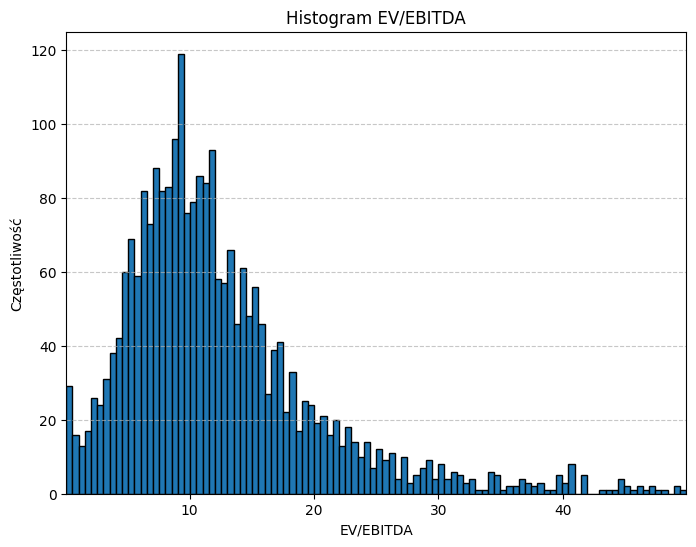

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df5['Enterprise_Value_over_EBITDA'], bins=100, edgecolor='black')
plt.title('EV/EBITDA Histogram')
plt.xlabel('EV/EBITDA')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(min(df5['Enterprise_Value_over_EBITDA']), max(df5['Enterprise_Value_over_EBITDA']))
plt.show()

In [24]:
df5['Enterprise_Value_over_EBITDA'].describe()

count    2460.000000
mean       12.396844
std         7.932509
min         0.063000
25%         7.262225
50%        10.685200
75%        15.428450
max        49.914300
Name: Enterprise_Value_over_EBITDA, dtype: float64

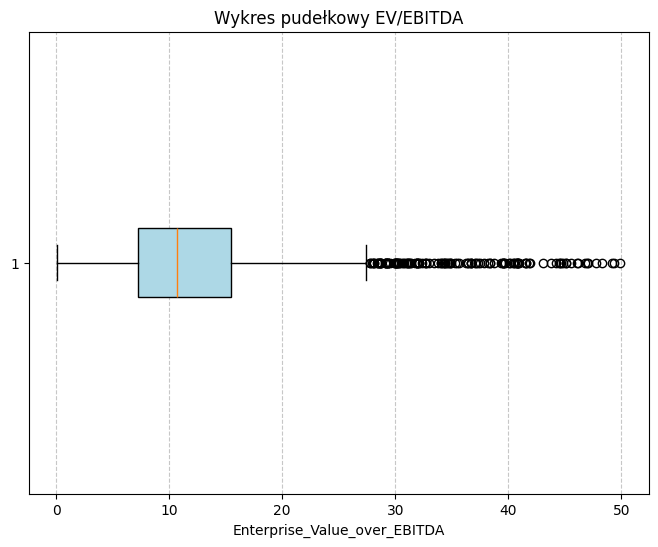

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df5['Enterprise_Value_over_EBITDA'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('EV/EBITDA Box Plot')
plt.xlabel('Enterprise Value over EBITDA')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [26]:
count = (df5['Revenue_Growth'] > 1).sum()
print(count)

39


In [27]:
percentiles2 = df5['Revenue_Growth'].quantile([i / 40 for i in range(41)])
print(percentiles2)

0.000    -0.994100
0.025    -0.151267
0.050    -0.073015
0.075    -0.041930
0.100    -0.023280
0.125    -0.010800
0.150    -0.000745
0.175     0.006032
0.200     0.015700
0.225     0.022955
0.250     0.030700
0.275     0.036868
0.300     0.041880
0.325     0.046900
0.350     0.053565
0.375     0.059400
0.400     0.064380
0.425     0.071015
0.450     0.076100
0.475     0.080602
0.500     0.086600
0.525     0.092498
0.550     0.099090
0.575     0.106200
0.600     0.113840
0.625     0.121100
0.650     0.128770
0.675     0.139882
0.700     0.151630
0.725     0.162200
0.750     0.175525
0.775     0.187673
0.800     0.202500
0.825     0.224770
0.850     0.249815
0.875     0.283687
0.900     0.322420
0.925     0.401488
0.950     0.509190
0.975     0.770203
1.000    20.024200
Name: Revenue_Growth, dtype: float64


In [28]:
df5['Revenue_Growth'].describe()

count    2460.000000
mean        0.148256
std         0.512795
min        -0.994100
25%         0.030700
50%         0.086600
75%         0.175525
max        20.024200
Name: Revenue_Growth, dtype: float64

In [98]:
output_path = Path("../data/processed/df_minimally_cleaned.csv")
df5.to_csv(output_path, index=False)

print(f"Saved df5 to: {output_path.resolve()}")
print(f"Shape: {df5.shape}")

Saved df5 to: C:\Users\tymot\OneDrive\Dokumenty\modeling_ev_ebitda_with_financial_ratios\data\processed\df_minimally_cleaned.csv
Shape: (2460, 14)


In [11]:
df7 = df5[df5['Revenue_Growth'].between(df5['Revenue_Growth'].quantile(0.025), df5['Revenue_Growth'].quantile(0.975))]
df7['Revenue_Growth'].describe()

count    2336.000000
mean        0.118668
std         0.139749
min        -0.150900
25%         0.033375
50%         0.086600
75%         0.168550
max         0.762800
Name: Revenue_Growth, dtype: float64

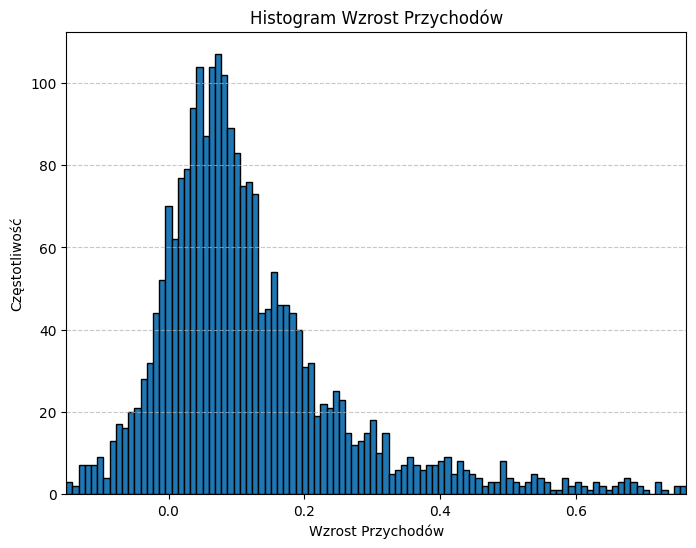

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df7['Revenue_Growth'], bins=100, edgecolor='black')
plt.title('Revenue Growth Histogram')
plt.xlabel('Revenue Growth')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(min(df7['Revenue_Growth']), max(df7['Revenue_Growth']))
plt.show()

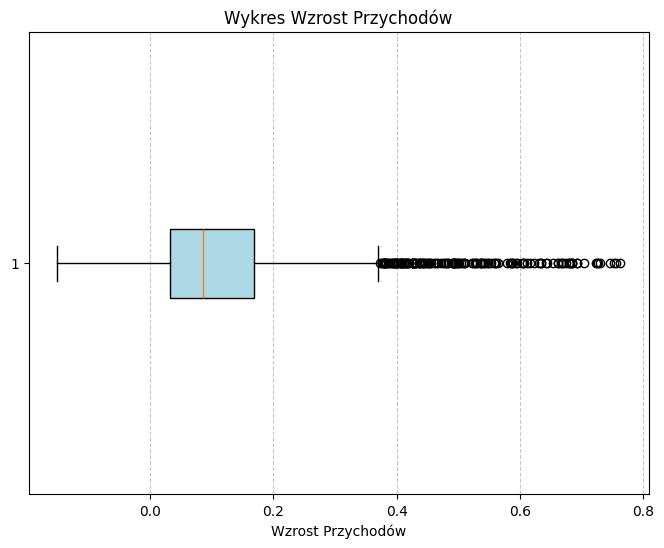

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df7['Revenue_Growth'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Revenue Growth Box Plot')
plt.xlabel('Revenue Growth')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [32]:
percentiles4 = df7['grossProfitMargin'].quantile([i / 40 for i in range(41)])
print(percentiles4)

0.000   -0.264888
0.025    0.095725
0.050    0.130133
0.075    0.150453
0.100    0.172026
0.125    0.189490
0.150    0.208591
0.175    0.225891
0.200    0.242108
0.225    0.260263
0.250    0.278037
0.275    0.294492
0.300    0.310746
0.325    0.327604
0.350    0.342895
0.375    0.356507
0.400    0.369757
0.425    0.385579
0.450    0.402467
0.475    0.424590
0.500    0.449272
0.525    0.473800
0.550    0.501406
0.575    0.528313
0.600    0.554049
0.625    0.581156
0.650    0.607560
0.675    0.639432
0.700    0.677629
0.725    0.711657
0.750    0.754965
0.775    0.803150
0.800    0.884656
0.825    1.000000
0.850    1.000000
0.875    1.000000
0.900    1.000000
0.925    1.000000
0.950    1.000000
0.975    1.000000
1.000    1.277431
Name: grossProfitMargin, dtype: float64


In [33]:
count = (df7['grossProfitMargin'] > 0.95).sum()
print(count)

437


In [34]:
df7 =  df7[(df7['grossProfitMargin'] >= 0) & (df7['grossProfitMargin'] <= 1)]
df7['grossProfitMargin'].describe()

count    2333.000000
mean        0.521427
std         0.297287
min         0.000171
25%         0.278137
50%         0.449288
75%         0.754456
max         1.000000
Name: grossProfitMargin, dtype: float64

In [35]:
percentiles4 = df7['grossProfitMargin'].quantile([i / 40 for i in range(41)])
print(percentiles4)

0.000    0.000171
0.025    0.096134
0.050    0.131996
0.075    0.151258
0.100    0.172246
0.125    0.190048
0.150    0.209028
0.175    0.226247
0.200    0.242457
0.225    0.260815
0.250    0.278137
0.275    0.294716
0.300    0.311023
0.325    0.327884
0.350    0.343131
0.375    0.356650
0.400    0.369816
0.425    0.385750
0.450    0.402493
0.475    0.424778
0.500    0.449288
0.525    0.473981
0.550    0.501460
0.575    0.528447
0.600    0.554181
0.625    0.581157
0.650    0.607602
0.675    0.639431
0.700    0.677411
0.725    0.711588
0.750    0.754456
0.775    0.802973
0.800    0.884113
0.825    1.000000
0.850    1.000000
0.875    1.000000
0.900    1.000000
0.925    1.000000
0.950    1.000000
0.975    1.000000
1.000    1.000000
Name: grossProfitMargin, dtype: float64


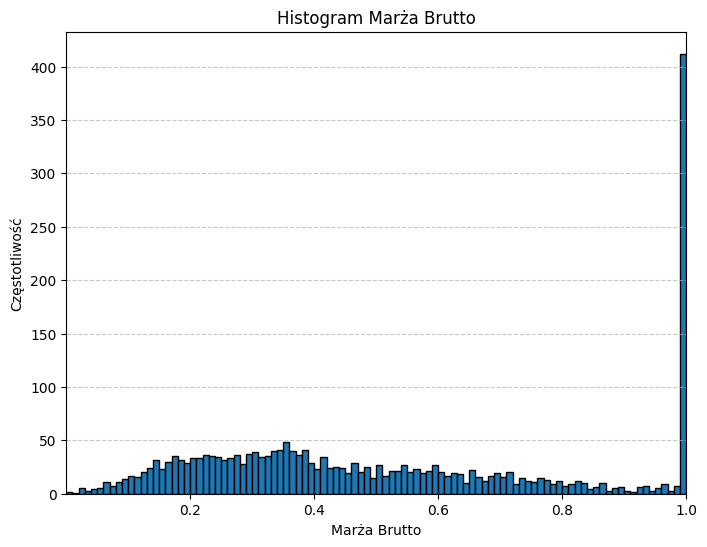

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df7['grossProfitMargin'], bins=100, edgecolor='black')
plt.title('Gross Profit Margin Histogram')
plt.xlabel('Gross Profit Margin')
plt.ylabel('Frequency')
plt.xlim(min(df7['grossProfitMargin']), max(df7['grossProfitMargin']))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

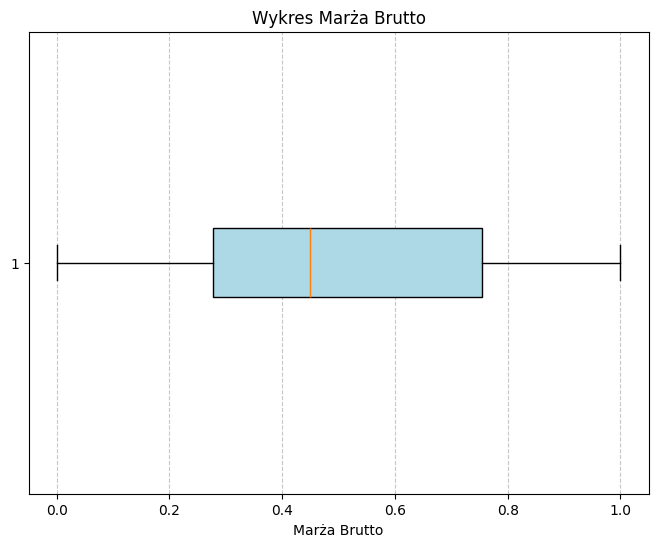

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df7['grossProfitMargin'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Gross Profit Margin Box Plot')
plt.xlabel('Gross Profit Margin')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [38]:
percentiles4 = df7['returnOnEquity'].quantile([i / 40 for i in range(41)])
print(percentiles4)

0.000   -39.63320
0.025    -0.51784
0.050    -0.14126
0.075    -0.06532
0.100    -0.02614
0.125    -0.00530
0.150     0.01054
0.175     0.02372
0.200     0.03244
0.225     0.04230
0.250     0.04930
0.275     0.05743
0.300     0.06446
0.325     0.07080
0.350     0.07680
0.375     0.08125
0.400     0.08638
0.425     0.09270
0.450     0.09628
0.475     0.10007
0.500     0.10500
0.525     0.11013
0.550     0.11470
0.575     0.12098
0.600     0.12632
0.625     0.13340
0.650     0.13940
0.675     0.14866
0.700     0.16014
0.725     0.17174
0.750     0.18410
0.775     0.19535
0.800     0.21020
0.825     0.23170
0.850     0.25446
0.875     0.28305
0.900     0.32260
0.925     0.39260
0.950     0.49610
0.975     0.83611
1.000    44.11630
Name: returnOnEquity, dtype: float64


In [39]:
count = (df7['returnOnEquity'] < -0.4).sum()
print(count)

72


In [40]:
df8 = df7[df7['returnOnEquity'].between(df7['returnOnEquity'].quantile(0.025), df7['returnOnEquity'].quantile(0.975))]
df8['returnOnEquity'].describe()

count    2215.000000
mean        0.123112
std         0.147987
min        -0.516300
25%         0.053850
50%         0.105000
75%         0.177450
max         0.822600
Name: returnOnEquity, dtype: float64

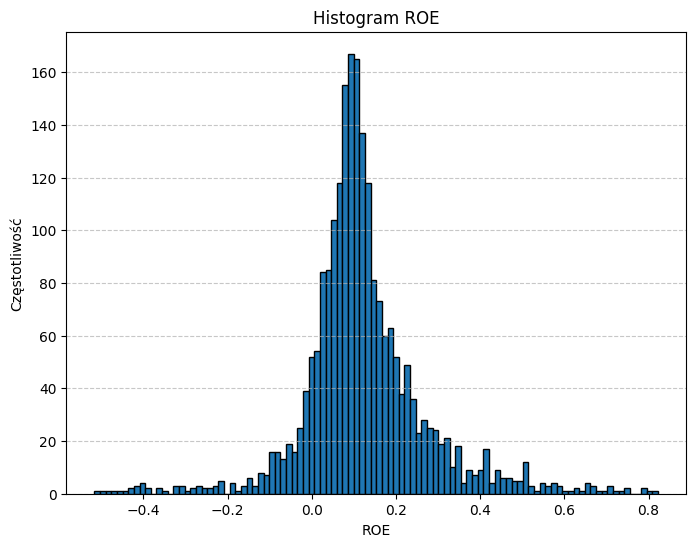

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df8['returnOnEquity'], bins=100, edgecolor='black')
plt.title('ROE Histogram')
plt.xlabel('ROE')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

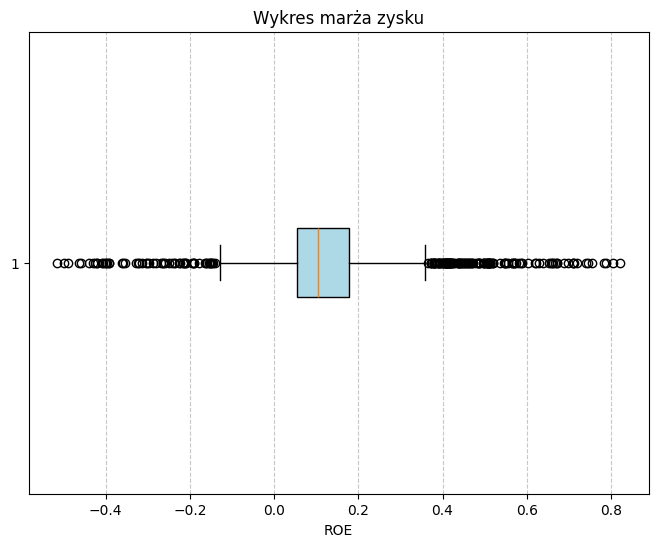

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df8['returnOnEquity'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Return on Equity Box Plot')
plt.xlabel('ROE')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [43]:
percentiles5 = df8['fixedAssetTurnover'].quantile([i / 40 for i in range(41)])
print(percentiles5)

0.000       0.050494
0.025       0.125342
0.050       0.164602
0.075       0.263978
0.100       0.337923
0.125       0.432147
0.150       0.642157
0.175       0.873007
0.200       1.212849
0.225       1.503270
0.250       1.789880
0.275       2.125102
0.300       2.327371
0.325       2.595027
0.350       2.819964
0.375       3.060274
0.400       3.303138
0.425       3.602535
0.450       3.841287
0.475       4.221127
0.500       4.629062
0.525       5.034629
0.550       5.406217
0.575       5.860923
0.600       6.291371
0.625       6.868507
0.650       7.335076
0.675       7.886755
0.700       8.588984
0.725       9.208240
0.750      10.336599
0.775      11.393233
0.800      12.812850
0.825      14.460905
0.850      16.827461
0.875      20.489605
0.900      25.030773
0.925      32.839574
0.950      43.798478
0.975      74.456951
1.000    2344.009053
Name: fixedAssetTurnover, dtype: float64


In [44]:
count = (df8['fixedAssetTurnover'] > 35).sum()
print(count)

157


In [45]:
df9 = df8[df8['fixedAssetTurnover'].between(df8['fixedAssetTurnover'].quantile(0), df8['fixedAssetTurnover'].quantile(0.95))]
df9['fixedAssetTurnover'].describe()

count    2104.000000
mean        7.042734
std         8.253429
min         0.050494
25%         1.634484
50%         4.218512
75%         8.797571
max        43.721530
Name: fixedAssetTurnover, dtype: float64

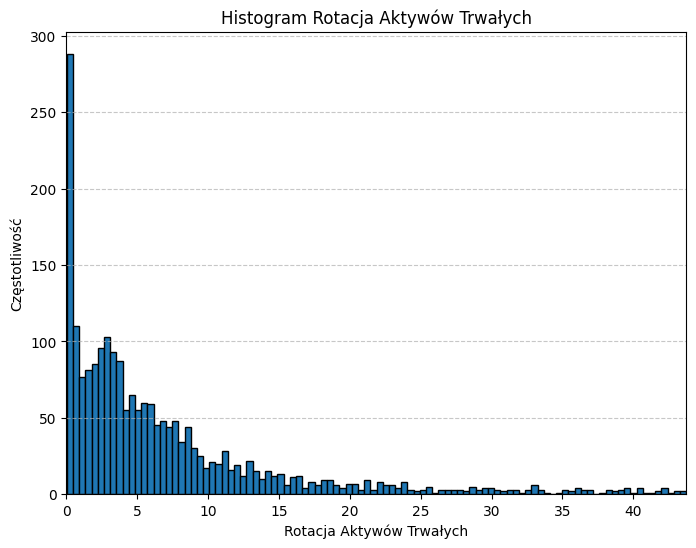

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df9['fixedAssetTurnover'], bins=100, edgecolor='black')
plt.title('Fixed Asset Turnover Histogram')
plt.xlabel('Fixed Asset Turnover')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df9['fixedAssetTurnover']))
plt.show()

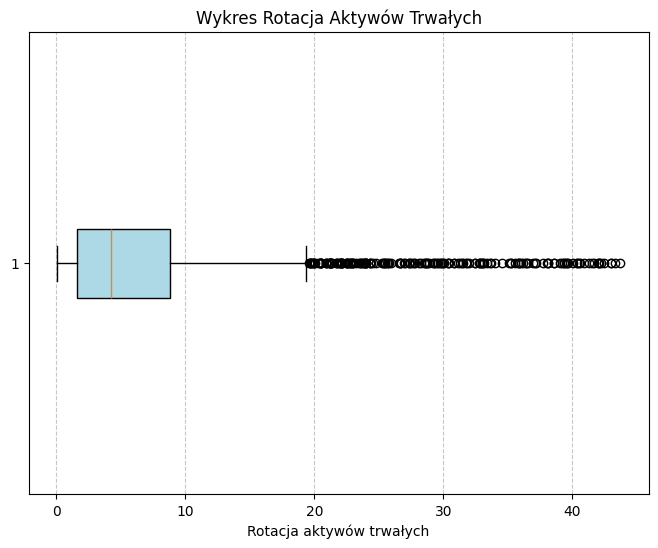

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df9['fixedAssetTurnover'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Fixed Asset Turnover Box Plot')
plt.xlabel('Fixed Asset Turnover')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [48]:
percentiles4 = df9['assetTurnover'].quantile([i / 40 for i in range(41)])
print(percentiles4)

0.000    0.004834
0.025    0.032574
0.050    0.036076
0.075    0.038878
0.100    0.042042
0.125    0.045769
0.150    0.055064
0.175    0.096287
0.200    0.126879
0.225    0.158336
0.250    0.208623
0.275    0.251872
0.300    0.288793
0.325    0.322552
0.350    0.359126
0.375    0.408627
0.400    0.443893
0.425    0.476781
0.450    0.517082
0.475    0.555704
0.500    0.597678
0.525    0.638461
0.550    0.682117
0.575    0.715171
0.600    0.757434
0.625    0.799513
0.650    0.845310
0.675    0.892724
0.700    0.952741
0.725    1.015353
0.750    1.093578
0.775    1.166384
0.800    1.251677
0.825    1.343661
0.850    1.430451
0.875    1.559322
0.900    1.698141
0.925    1.842179
0.950    2.053336
0.975    2.461664
1.000    6.276089
Name: assetTurnover, dtype: float64


In [49]:
count = (df9['assetTurnover'] > 3).sum()
print(count)

25


In [50]:
df10 = df9[df9['assetTurnover'].between(df9['assetTurnover'].quantile(0.025), df9['assetTurnover'].quantile(0.975))]
df10['assetTurnover'].describe()

count    1998.000000
mean        0.709050
std         0.575316
min         0.032585
25%         0.230616
50%         0.597678
75%         1.047405
max         2.455339
Name: assetTurnover, dtype: float64

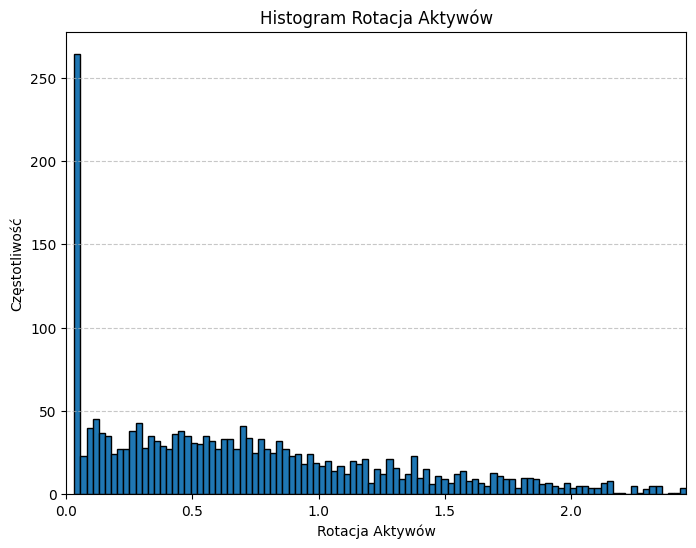

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df10['assetTurnover'], bins=100, edgecolor='black')
plt.title('Asset Turnover Histogram')
plt.xlabel('Asset Turnover')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df10['assetTurnover']))
plt.show()

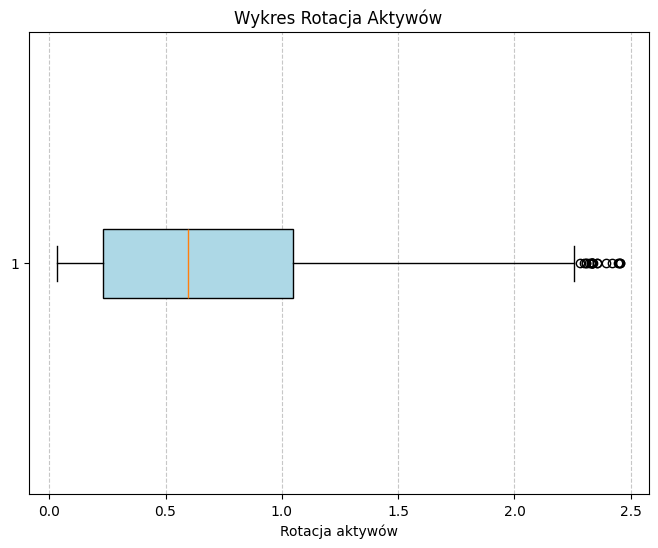

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df10['assetTurnover'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Asset Turnover Box Plot')
plt.xlabel('Asset Turnover')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [53]:
percentiles6 = df10['Debt_to_Equity'].quantile([i / 40 for i in range(41)])
print(percentiles6)

0.000   -148.516500
0.025      0.000000
0.050      0.000000
0.075      0.000000
0.100      0.000000
0.125      0.004138
0.150      0.049510
0.175      0.098800
0.200      0.136860
0.225      0.188830
0.250      0.233125
0.275      0.272688
0.300      0.316900
0.325      0.349118
0.350      0.391340
0.375      0.426375
0.400      0.463000
0.425      0.500200
0.450      0.545495
0.475      0.585330
0.500      0.647600
0.525      0.702927
0.550      0.740960
0.575      0.777465
0.600      0.816760
0.625      0.869750
0.650      0.920220
0.675      0.978180
0.700      1.034080
0.725      1.098595
0.750      1.156875
0.775      1.242490
0.800      1.347120
0.825      1.469130
0.850      1.606895
0.875      1.861475
0.900      2.171830
0.925      2.547185
0.950      3.083665
0.975      4.453090
1.000     46.939800
Name: Debt_to_Equity, dtype: float64


In [54]:
count = (df10['Debt_to_Equity'] > 4.5).sum()
print(count)

50


In [55]:
df11 = df10[df10['Debt_to_Equity'].between(df10['Debt_to_Equity'].quantile(0.025), df10['Debt_to_Equity'].quantile(0.975))]
df11['Debt_to_Equity'].describe()

count    1903.000000
mean        0.836129
std         0.825956
min         0.000000
25%         0.244600
50%         0.645800
75%         1.126350
max         4.438900
Name: Debt_to_Equity, dtype: float64

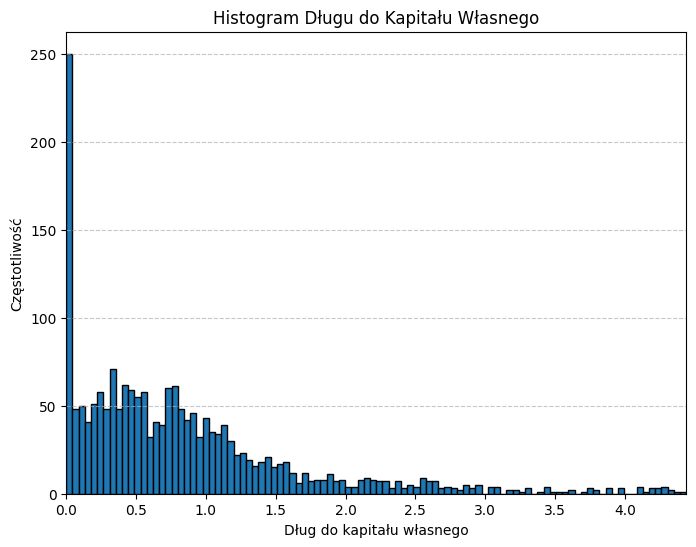

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df11['Debt_to_Equity'], bins=100, edgecolor='black')
plt.title('Debt-to-Equity Histogram')
plt.xlabel('Debt-to-Equity Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df11['Debt_to_Equity']))
plt.show()

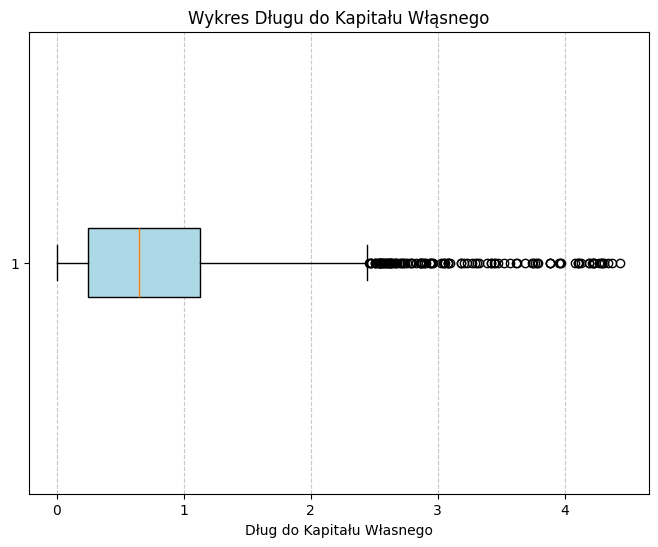

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df11['Debt_to_Equity'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Debt-to-Equity Box Plot')
plt.xlabel('Debt-to-Equity Ratio')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [58]:
percentiles6 = df11['Capex_to_Revenue'].quantile([i / 40 for i in range(41)])
print(percentiles6)

0.000   -1.860600
0.025    0.000000
0.050    0.004200
0.075    0.006800
0.100    0.008900
0.125    0.010800
0.150    0.012530
0.175    0.013900
0.200    0.015700
0.225    0.017000
0.250    0.018400
0.275    0.020200
0.300    0.021500
0.325    0.023300
0.350    0.025070
0.375    0.026900
0.400    0.028580
0.425    0.030300
0.450    0.032090
0.475    0.034145
0.500    0.036000
0.525    0.038500
0.550    0.041410
0.575    0.044665
0.600    0.048000
0.625    0.051775
0.650    0.055000
0.675    0.059300
0.700    0.065420
0.725    0.071100
0.750    0.079950
0.775    0.089705
0.800    0.107220
0.825    0.130465
0.850    0.163940
0.875    0.208750
0.900    0.280560
0.925    0.355840
0.950    0.482710
0.975    0.745495
1.000    7.409800
Name: Capex_to_Revenue, dtype: float64


In [59]:
count = (df11['Capex_to_Revenue'] > 0.8).sum()
print(count)

45


In [60]:
df12 = df11[df11['Capex_to_Revenue'] >= 0]
df12 = df11[df11['Capex_to_Revenue'].between(df11['Capex_to_Revenue'].quantile(0), df11['Capex_to_Revenue'].quantile(0.975))]
df12['Capex_to_Revenue'].describe()

count    1855.000000
mean        0.074434
std         0.143043
min        -1.860600
25%         0.018200
50%         0.035200
75%         0.073550
max         0.743200
Name: Capex_to_Revenue, dtype: float64

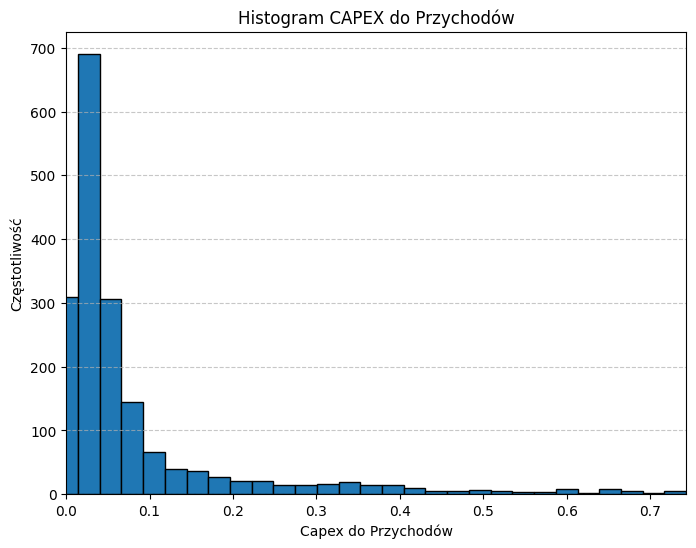

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df12['Capex_to_Revenue'], bins=100, edgecolor='black')
plt.title('CAPEX to Revenue Histogram')
plt.xlabel('CAPEX to Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df12['Capex_to_Revenue']))
plt.show()

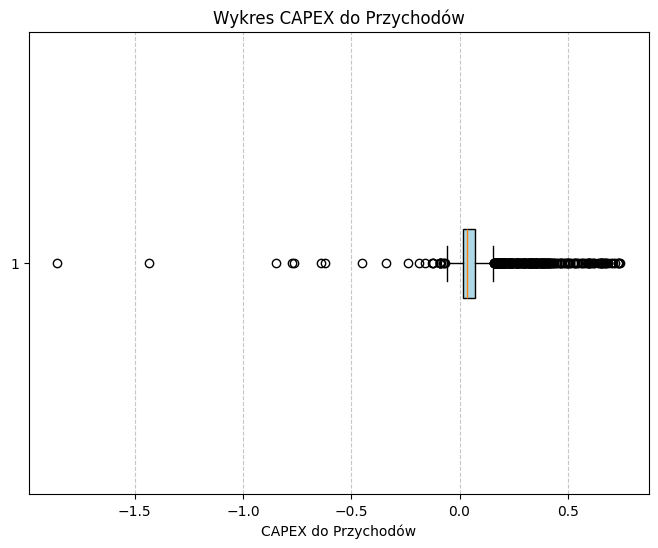

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df12['Capex_to_Revenue'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('CAPEX to Revenue Box Plot')
plt.xlabel('CAPEX to Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [63]:
percentiles7 = df12['R&D_to_Revenue'].quantile([i / 40 for i in range(41)])
print(percentiles7)

0.000    0.000000
0.025    0.000000
0.050    0.000000
0.075    0.000000
0.100    0.000000
0.125    0.000000
0.150    0.000000
0.175    0.000000
0.200    0.000000
0.225    0.000000
0.250    0.000000
0.275    0.000000
0.300    0.000000
0.325    0.000000
0.350    0.000000
0.375    0.000000
0.400    0.000000
0.425    0.000000
0.450    0.000000
0.475    0.000000
0.500    0.000000
0.525    0.000000
0.550    0.000000
0.575    0.000000
0.600    0.000000
0.625    0.000000
0.650    0.000000
0.675    0.000000
0.700    0.000000
0.725    0.000000
0.750    0.000000
0.775    0.008985
0.800    0.020420
0.825    0.033665
0.850    0.044670
0.875    0.063025
0.900    0.082820
0.925    0.110590
0.950    0.144190
0.975    0.191785
1.000    7.655100
Name: R&D_to_Revenue, dtype: float64


In [64]:
count = (df12['R&D_to_Revenue'] >= 0.4).sum()
print(count)

6


In [65]:
df12 = df12[df12['R&D_to_Revenue'] >= 0]
df12 = df12[df12['R&D_to_Revenue'].between(df12['R&D_to_Revenue'].quantile(0), df12['R&D_to_Revenue'].quantile(0.975))]
df12['R&D_to_Revenue'].describe()

count    1808.000000
mean        0.015339
std         0.037474
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.191200
Name: R&D_to_Revenue, dtype: float64

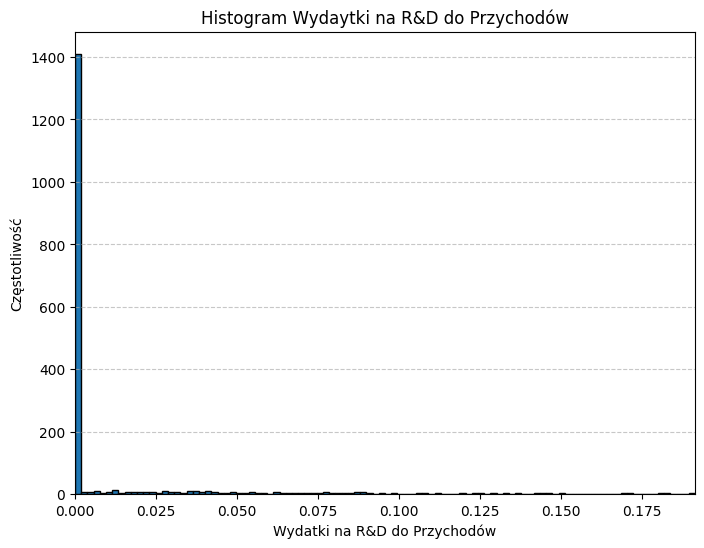

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df12['R&D_to_Revenue'], bins=100, edgecolor='black')
plt.title('R&D Spending to Revenue Histogram')
plt.xlabel('R&D Spending to Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df12['R&D_to_Revenue']))
plt.show()

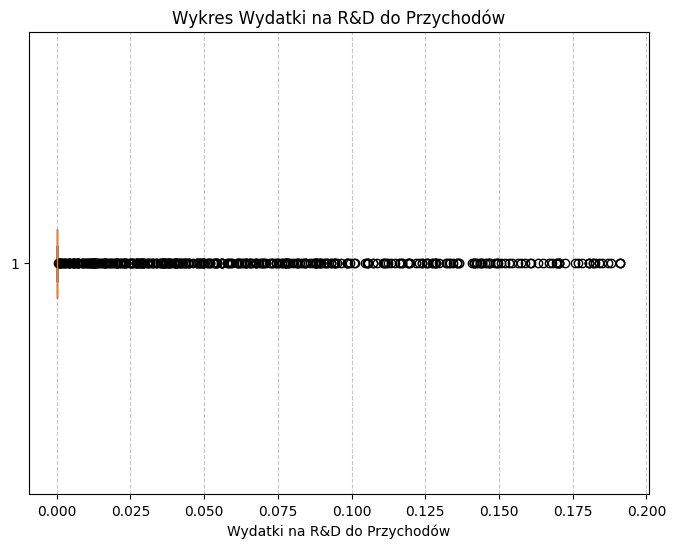

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df12['R&D_to_Revenue'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('R&D Spending to Revenue Box Plot')
plt.xlabel('R&D Spending to Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [68]:
percentiles8 = df12['Dividend_Yield'].quantile([i / 40 for i in range(41)])
print(percentiles8)

0.000    0.000000
0.025    0.000000
0.050    0.000000
0.075    0.000000
0.100    0.000000
0.125    0.000000
0.150    0.000000
0.175    0.000000
0.200    0.000000
0.225    0.000000
0.250    0.000000
0.275    0.000000
0.300    0.000000
0.325    0.000000
0.350    0.001390
0.375    0.005000
0.400    0.007000
0.425    0.009300
0.450    0.011000
0.475    0.012300
0.500    0.013500
0.525    0.014900
0.550    0.016400
0.575    0.017800
0.600    0.019400
0.625    0.021300
0.650    0.023055
0.675    0.024973
0.700    0.026290
0.725    0.027900
0.750    0.029325
0.775    0.031100
0.800    0.033000
0.825    0.035700
0.850    0.039400
0.875    0.043612
0.900    0.050600
0.925    0.060890
0.950    0.077630
0.975    0.113025
1.000    0.893000
Name: Dividend_Yield, dtype: float64


In [69]:
df12 = df12[df12['Dividend_Yield'] >= 0]
df12 = df12[df12['Dividend_Yield'].between(df12['Dividend_Yield'].quantile(0), df12['Dividend_Yield'].quantile(0.975))]
df12['Dividend_Yield'].describe()

count    1762.000000
mean        0.018051
std         0.021131
min         0.000000
25%         0.000000
50%         0.012900
75%         0.028200
max         0.112200
Name: Dividend_Yield, dtype: float64

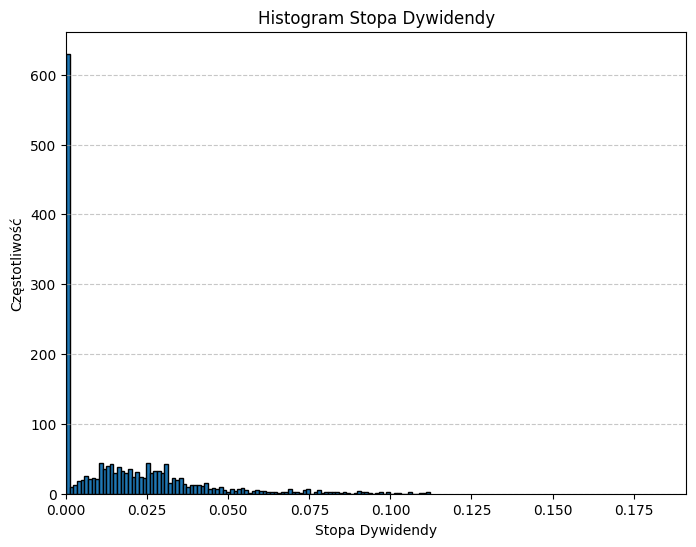

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df12['Dividend_Yield'], bins=100, edgecolor='black')
plt.title('Dividend Yield Histogram')
plt.xlabel('Dividend Yield')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(df12['R&D_to_Revenue']))
plt.show()

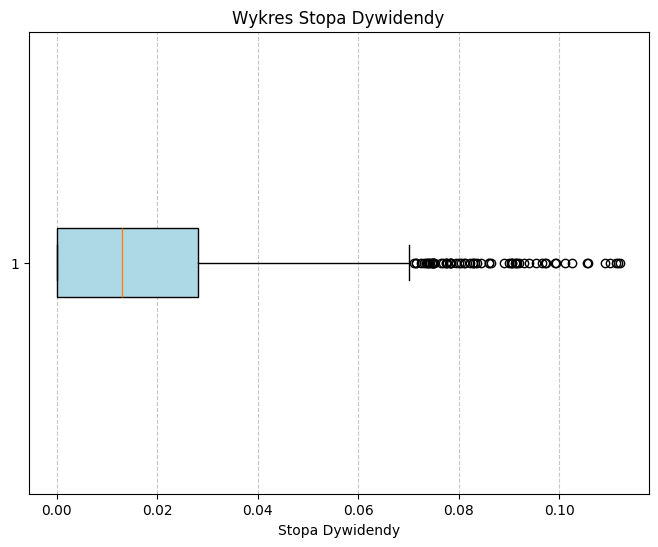

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df12['Dividend_Yield'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Dividend Yield Box Plot')
plt.xlabel('Dividend Yield')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [72]:
percentiles9 = df12['currentRatio'].quantile([i / 40 for i in range(41)])
print(percentiles9)

0.000     0.012565
0.025     0.028575
0.050     0.039109
0.075     0.049281
0.100     0.068773
0.125     0.101056
0.150     0.250493
0.175     0.478000
0.200     0.590193
0.225     0.715714
0.250     0.809250
0.275     0.887702
0.300     0.987242
0.325     1.056000
0.350     1.129350
0.375     1.215375
0.400     1.282800
0.425     1.358425
0.450     1.422800
0.475     1.473475
0.500     1.543874
0.525     1.624000
0.550     1.701100
0.575     1.799150
0.600     1.860400
0.625     1.935000
0.650     2.009650
0.675     2.130310
0.700     2.268700
0.725     2.377725
0.750     2.514500
0.775     2.654100
0.800     2.788600
0.825     2.987850
0.850     3.193800
0.875     3.525750
0.900     4.073400
0.925     4.698325
0.950     5.671350
0.975     7.878775
1.000    33.035000
Name: currentRatio, dtype: float64


In [73]:
count = (df12['currentRatio'] >= 7.8).sum()
print(count)

49


In [74]:
df14 = df12[df12['currentRatio'].between(df12['currentRatio'].quantile(0.25), df12['currentRatio'].quantile(0.975))]
df14['currentRatio'].describe()

count    1276.000000
mean        2.288411
std         1.331703
min         0.810000
25%         1.373570
50%         1.896500
75%         2.764000
max         7.870000
Name: currentRatio, dtype: float64

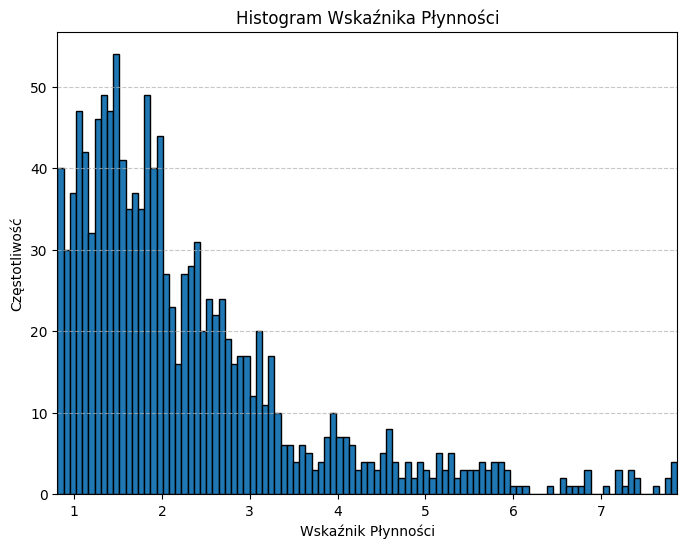

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['currentRatio'], bins=100, edgecolor='black')
plt.title('Liquidity Ratio Histogram')
plt.xlabel('Liquidity Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(min(df14['currentRatio']), max(df14['currentRatio']))
plt.show()

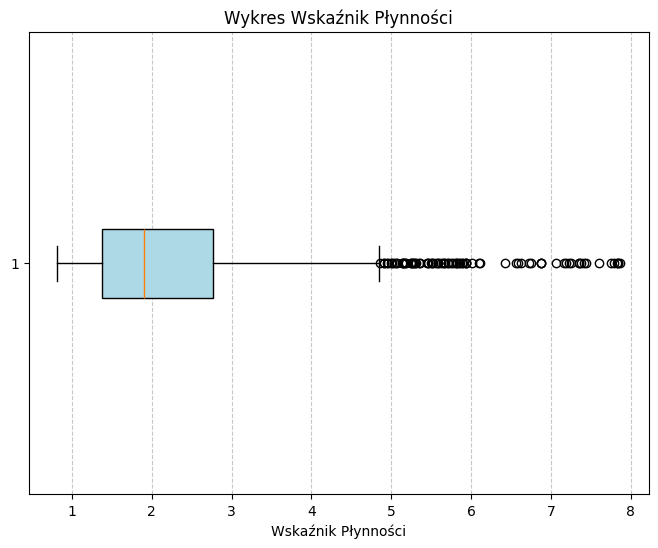

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df14['currentRatio'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Liquidity Ratio Box Plot')
plt.xlabel('Liquidity Ratio')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Histograms of Explanatory Variables

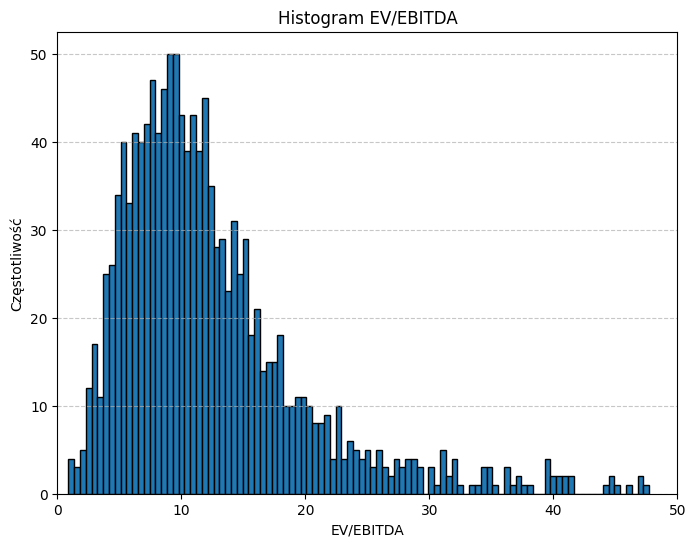

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Enterprise_Value_over_EBITDA'], bins=100, edgecolor='black')
plt.title('EV/EBITDA Histogram')
plt.xlabel('EV/EBITDA')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 50)
plt.show()

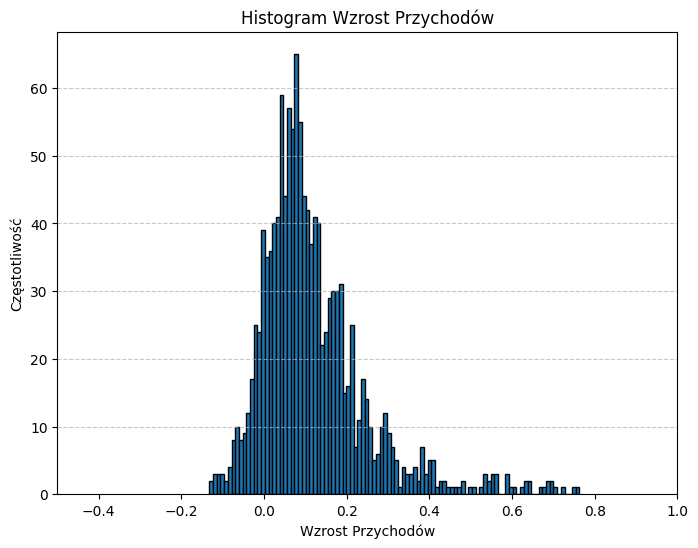

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Revenue_Growth'], bins=100, edgecolor='black')
plt.title('Revenue Growth Histogram')
plt.xlabel('Revenue Growth')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-0.5, 1)
plt.show()

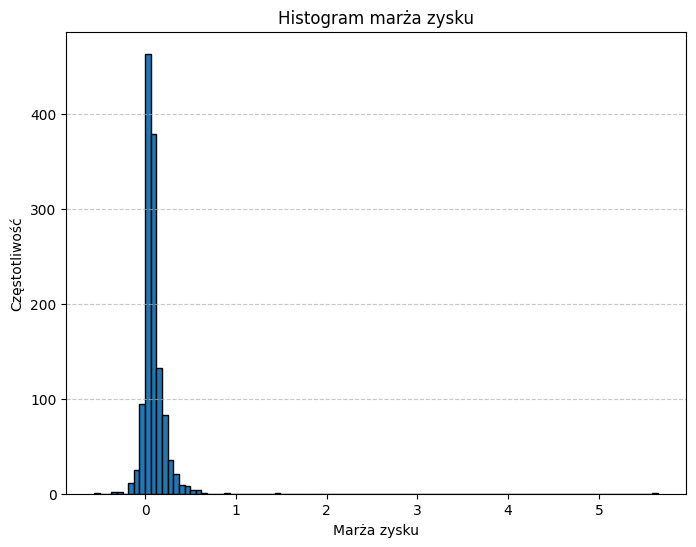

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Profit_Margin'], bins=100, edgecolor='black')
plt.title('Profit Margin Histogram')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

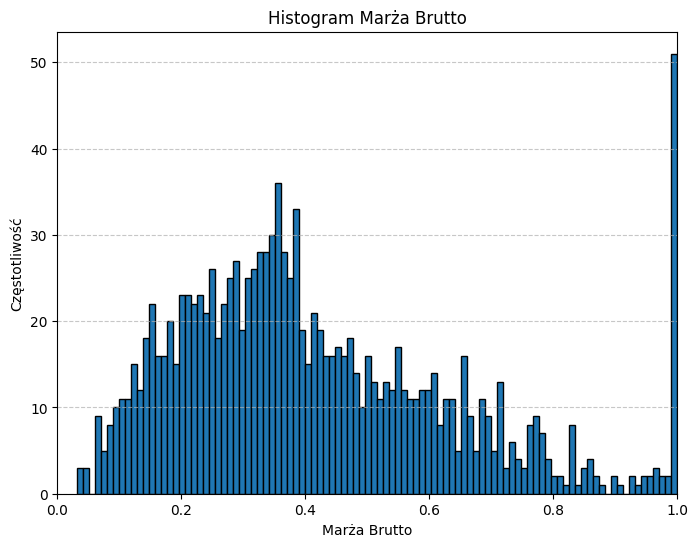

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['grossProfitMargin'], bins=100, edgecolor='black')
plt.title('Gross Profit Margin Histogram')
plt.xlabel('Gross Profit Margin')
plt.ylabel('Frequency')
plt.xlim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

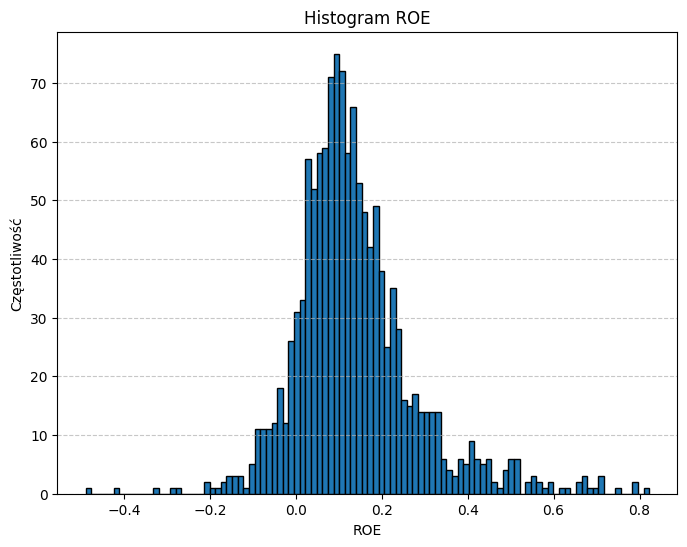

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['returnOnEquity'], bins=100, edgecolor='black')
plt.title('ROE Histogram')
plt.xlabel('ROE')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

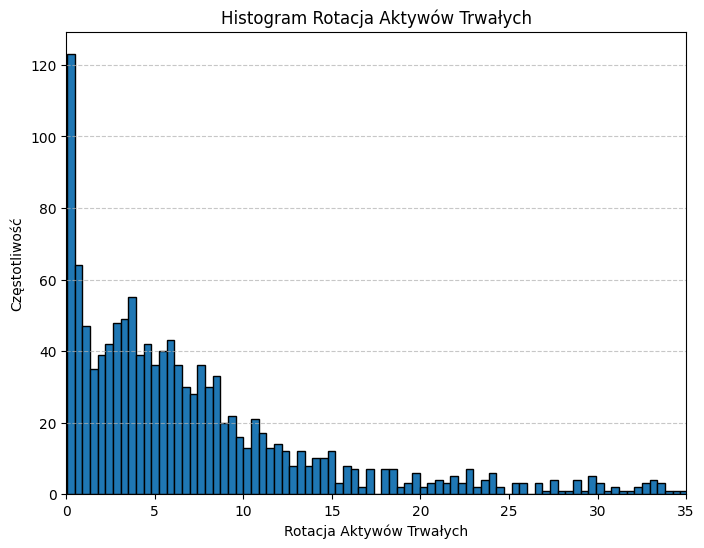

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['fixedAssetTurnover'], bins=100, edgecolor='black')
plt.title('Fixed Asset Turnover Histogram')
plt.xlabel('Fixed Asset Turnover')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,35)
plt.show()

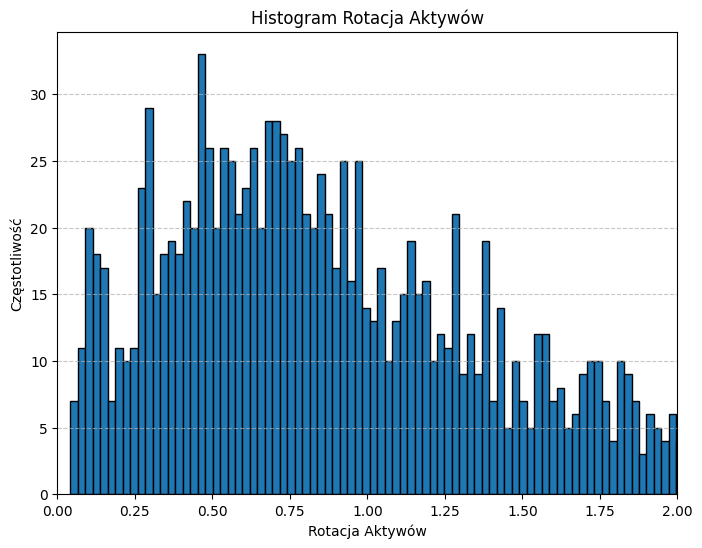

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['assetTurnover'], bins=100, edgecolor='black')
plt.title('Asset Turnover Histogram')
plt.xlabel('Asset Turnover')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,2)
plt.show()

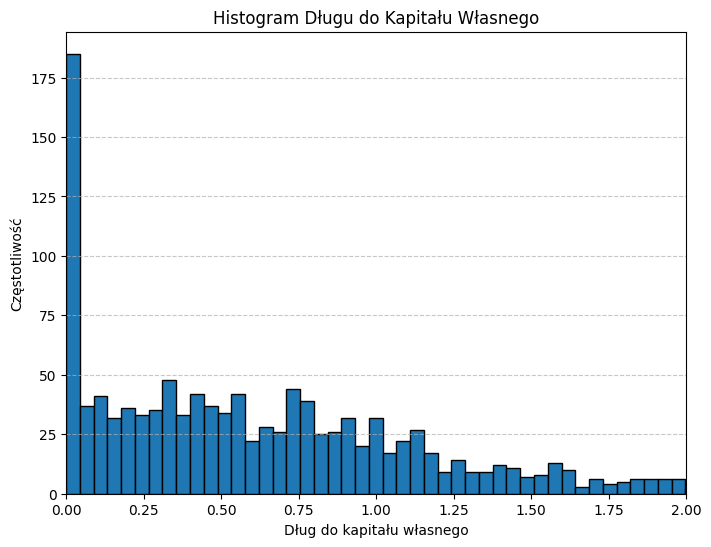

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Debt_to_Equity'], bins=100, edgecolor='black')
plt.title('Debt-to-Equity Histogram')
plt.xlabel('Debt-to-Equity Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,2)
plt.show()

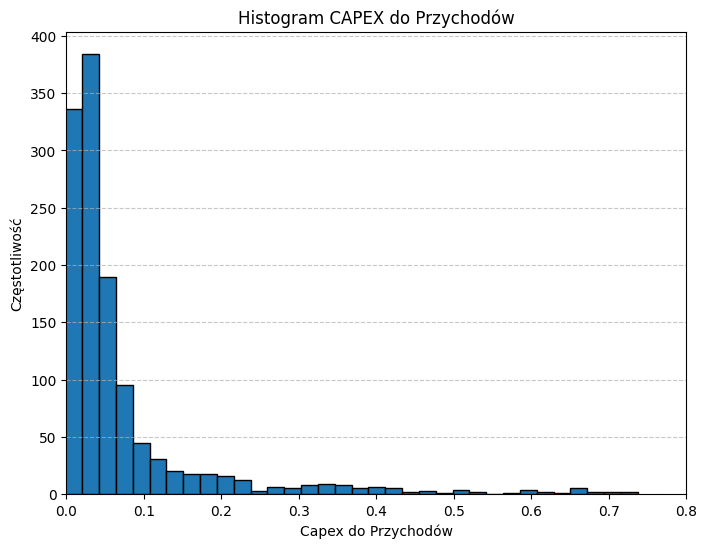

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Capex_to_Revenue'], bins=100, edgecolor='black')
plt.title('CAPEX to Revenue Histogram')
plt.xlabel('CAPEX to Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,0.8)
plt.show()

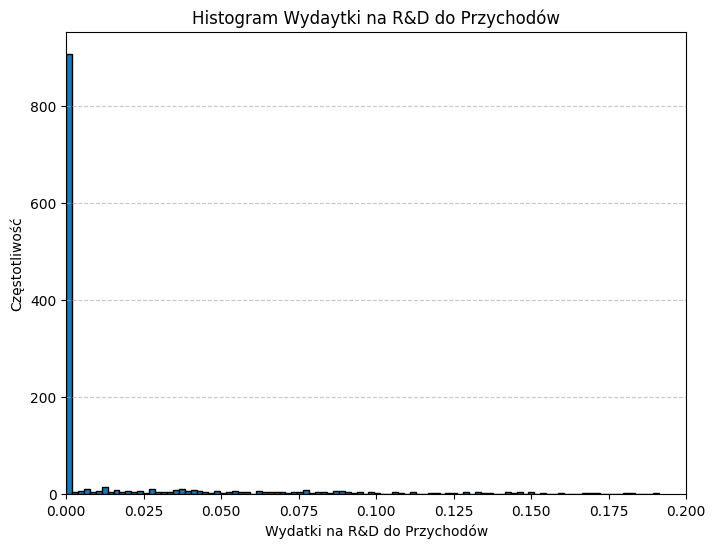

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['R&D_to_Revenue'], bins=100, edgecolor='black')
plt.title('R&D Spending to Revenue Histogram')
plt.xlabel('R&D Spending to Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,0.2)
plt.show()

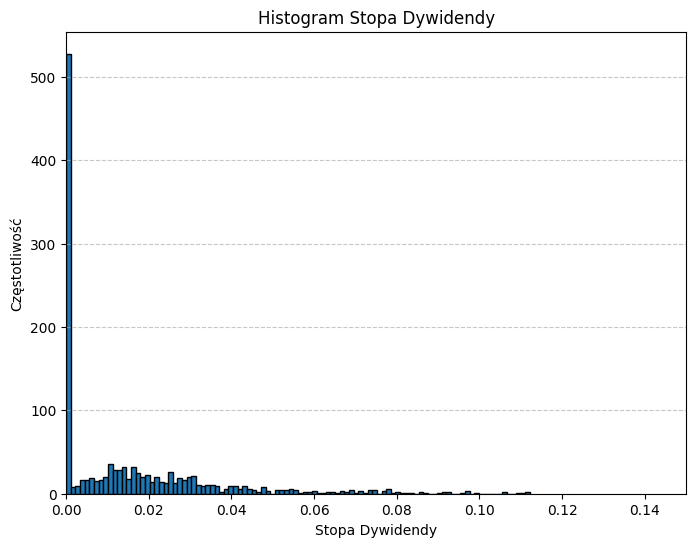

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['Dividend_Yield'], bins=100, edgecolor='black')
plt.title('Dividend Yield Histogram')
plt.xlabel('Dividend Yield')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,0.15)
plt.show()

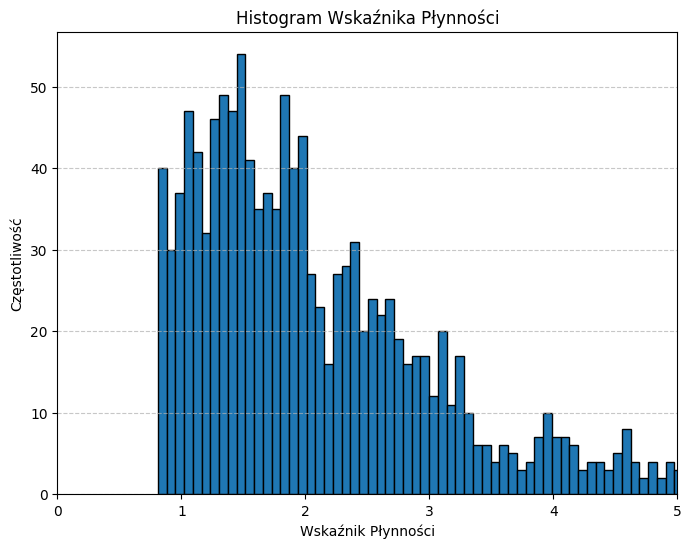

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df14['currentRatio'], bins=100, edgecolor='black')
plt.title('Liquidity Ratio Histogram')
plt.xlabel('Liquidity Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,5)
plt.show()

In [96]:
output_path = Path("../data/processed/df_cleaned.csv")
df14.to_csv(output_path, index=False)

print(f"Saved df14 to: {output_path.resolve()}")
print(f"Shape: {df14.shape}")

Saved df14 to: C:\Users\tymot\OneDrive\Dokumenty\modeling_ev_ebitda_with_financial_ratios\data\processed\df_cleaned.csv
Shape: (1276, 14)


## Financial-Economic Interpretation of the Final Cleaned Sample

After sequential trimming and range restrictions, the final dataset is best interpreted as a core, economically comparable universe of listed firms rather than the full raw population.

Key implications for downstream modeling:
- Coefficients and feature importances will describe pricing relations inside the tradable core of firms, not necessarily distressed outliers.
- Outlier control improves estimator stability and reduces leverage of single observations, which is crucial for both WLS diagnostics and tree-based models.
- Remaining cross-sectional dispersion is still meaningful: differences in profitability, leverage, investment intensity, and innovation profile can now be interpreted as genuine valuation drivers rather than data artifacts.

Business interpretation angle:
- Higher valuation multiples in the cleaned sample are expected to be associated with combinations of stronger margins, credible growth, and sustainable balance-sheet quality.
- Sector and business-model effects remain relevant; therefore, later cluster and sector-aware analyses should be read as complementary to global models.

Limitations to keep explicit in reporting:
- Threshold-based cleaning always embeds judgment and may remove some valid extreme firms.
- Results should be described as robust for mainstream listed-company profiles, with caution when extrapolating to turnaround, deep-cyclical, or highly idiosyncratic cases.